### Install pre-requistes


In [1]:
!pip install --upgrade SPARQLWrapper pandas matplotlib --quiet


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ENDPOINT_URL = "http://localhost:7200/repositories/KG-Questionnarie"

PREFIXES = """\
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ds:   <http://digistrucmed.org/questionnaire#>
"""

In [3]:
def run_query(query: str) -> pd.DataFrame:
    """Run a SPARQL SELECT query and return the results as a Pandas DataFrame."""
    sparql = SPARQLWrapper(ENDPOINT_URL)
    sparql.setReturnFormat(JSON)
    sparql.setQuery(PREFIXES + "\n" + query)
    results = sparql.query().convert()

    cols = results["head"].get("vars", [])
    rows = []
    for b in results["results"]["bindings"]:
        row = {}
        for c in cols:
            val = b.get(c, {}).get("value")
            row[c] = val
        rows.append(row)
    return pd.DataFrame(rows, columns=cols)

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_colwidth", 120)

## 1. Overview: all instances and their types

This query gives a quick overview of the entities in your graph and their Boxology types.


In [4]:
q1 = """\
SELECT DISTINCT ?type
WHERE {
  ?entity rdf:type ?type .
}
"""
df1 = run_query(q1)
df1.head(50)

,type
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#Property
1,http://www.w3.org/2002/07/owl#TransitiveProperty
2,http://www.w3.org/2002/07/owl#SymmetricProperty
3,http://www.w3.org/1999/02/22-rdf-syntax-ns#List
4,http://www.w3.org/2000/01/rdf-schema#Class
5,http://www.w3.org/2000/01/rdf-schema#Datatype
6,http://www.w3.org/2000/01/rdf-schema#ContainerMembershipProperty
7,http://digistrucmed.org/questionnaire#Question
8,http://digistrucmed.org/questionnaire#Questionnaire
9,http://digistrucmed.org/questionnaire#ModuleEvaluation


## 2. Distribution of instances per class

Counts how many instances there are of each Boxology class.

In [5]:
q2 = """\
SELECT DISTINCT ?type (COUNT(?instance) AS ?count)
WHERE {
  ?instance rdf:type ?type .
}
GROUP BY ?type
ORDER BY DESC(?count)
"""

df2 = run_query(q2)
df2

,type,count
0,http://digistrucmed.org/questionnaire#Answered,3154
1,http://digistrucmed.org/questionnaire#Answer,310
2,http://digistrucmed.org/questionnaire#User,273
3,http://digistrucmed.org/questionnaire#Nominal,151
4,http://digistrucmed.org/questionnaire#Ordinal,115
5,http://digistrucmed.org/questionnaire#Question,42
6,http://digistrucmed.org/questionnaire#NullAnswer,42
7,http://www.w3.org/1999/02/22-rdf-syntax-ns#Property,39
8,http://www.w3.org/2002/07/owl#TransitiveProperty,4
9,http://www.w3.org/2002/07/owl#SymmetricProperty,4


C:\Users\tehranim.TIB.001\AppData\Local\Temp\ipykernel_3920\1911753769.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


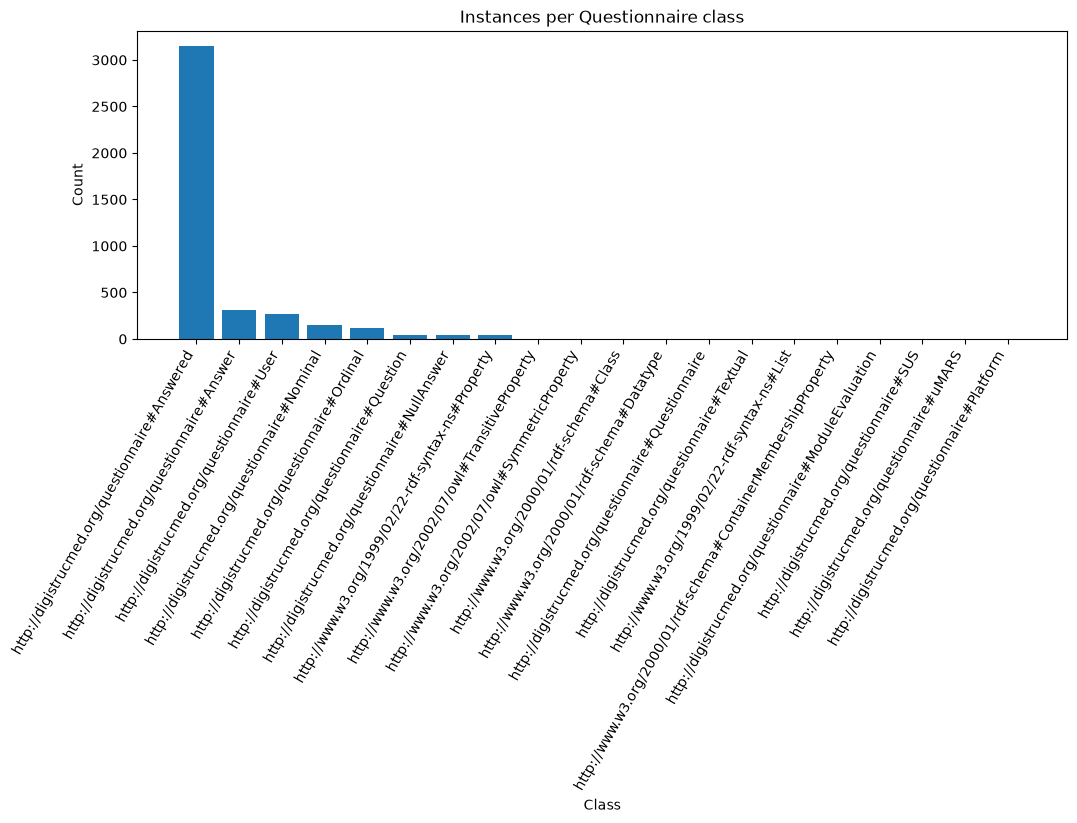

In [6]:

if not df2.empty:
    df2_plot = df2.copy()
    df2_plot["count"] = pd.to_numeric(df2_plot["count"], errors="coerce")
    df2_plot = df2_plot.dropna(subset=["count"])
    plt.figure(figsize=(12, 4))
    plt.xticks(rotation=60, ha="right")
    plt.title("Instances per Questionnaire class")
    plt.ylabel("Count")
    plt.xlabel("Class")
    plt.bar(df2_plot["type"], df2_plot["count"])
    plt.tight_layout()
else:
    print("No data to plot for query 2.")

## 3. List the number of answers are answered by users in each questionnarie.


In [7]:
q3 = """\
SELECT DISTINCT ?user (COUNT(?instance) AS ?count) ?questionnarie
WHERE {
  ?instance rdf:type <http://digistrucmed.org/questionnaire#Answered>;
    <http://digistrucmed.org/questionnaire#answeredByUser> ?user;
    <http://digistrucmed.org/questionnaire#answeredInQuestionnaire> ?questionnarie.
}
GROUP BY ?user ?questionnarie
ORDER BY DESC(?count)
"""

df3 = run_query(q3)
df3

,user,count,questionnarie
0,http://digistrucmed.org/questionnaire#50,24,http://digistrucmed.org/questionnaire#uMARS
1,http://digistrucmed.org/questionnaire#55,24,http://digistrucmed.org/questionnaire#uMARS
2,http://digistrucmed.org/questionnaire#81,24,http://digistrucmed.org/questionnaire#uMARS
3,http://digistrucmed.org/questionnaire#100,24,http://digistrucmed.org/questionnaire#uMARS
4,http://digistrucmed.org/questionnaire#127,24,http://digistrucmed.org/questionnaire#uMARS
...,...,...,...
268,http://digistrucmed.org/questionnaire#425,8,http://digistrucmed.org/questionnaire#ME1
269,http://digistrucmed.org/questionnaire#426,8,http://digistrucmed.org/questionnaire#ME1
270,http://digistrucmed.org/questionnaire#427,8,http://digistrucmed.org/questionnaire#ME1
271,http://digistrucmed.org/questionnaire#429,8,http://digistrucmed.org/questionnaire#ME1


## 4.Network Degree Centrality of Questionnaire Entities
Using predicate edges.

Number of nodes: 3783
Number of edges: 16122


,node,centrality
3782,http://digistrucmed.org/questionnaire#1,0.833950
1,http://digistrucmed.org/questionnaire#ME1,0.353252
21,http://digistrucmed.org/questionnaire#uMARS,0.349022
10,http://digistrucmed.org/questionnaire#SUS,0.142782
2,http://digistrucmed.org/questionnaire#M003_01,0.047329
5,http://digistrucmed.org/questionnaire#M006_01,0.047329
3,http://digistrucmed.org/questionnaire#M004_01,0.047329
0,http://digistrucmed.org/questionnaire#M002_01,0.047329
8,http://digistrucmed.org/questionnaire#M010_01,0.047329
4,http://digistrucmed.org/questionnaire#M005,0.045479


Average number of neighbors (overall): 8.523394131641554
Average number of neighbors (patterns only): 6.486023958927553
Average number of neighbors (data nodes only): 34.31046931407942
Average shortest path length (largest component): 2.3376582565578734


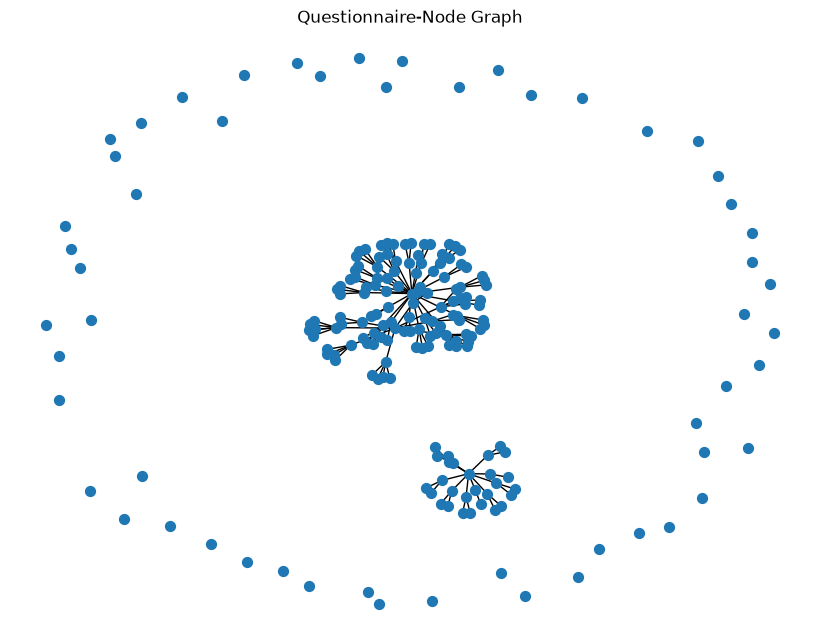

In [ ]:
# Build a Questionnaire relations
q_edges = """
SELECT ?s ?p ?o
WHERE {
  ?s ?p ?o .
  FILTER(?p IN (
    ds:belongsTo,
    ds:hasPossibleAnswer,
    ds:isAnswerTo,
    ds:answeredByUser,
    ds:answeredOnPlatform,
    ds:answeredInQuestionnaire,
    ds:hasQuestion,
    ds:hasAnswer
  ))
  FILTER(isIRI(?s) && isIRI(?o))
}
"""

# Run query
df_edges = run_query(q_edges)

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

G = nx.Graph()
for _, r in df_edges.iterrows():
    G.add_edge(r['s'], r['o'])

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# Degree centrality for all nodes
deg_centrality = nx.degree_centrality(G)

# Convert to DataFrame and show top 20 most central nodes
df_deg = (
    pd.DataFrame(deg_centrality.items(), columns=['node', 'centrality'])
      .sort_values('centrality', ascending=False)
)

display(df_deg.head(20))

# --- Average number of neighbors (average degree) ---
degrees = dict(G.degree())
if len(degrees) > 0:
    avg_neighbors = sum(degrees.values()) / len(degrees)
else:
    avg_neighbors = 0

print("Average number of neighbors (overall):", avg_neighbors)

# --- Restrict to pattern nodes only ---
pattern_nodes = set(df_edges['s'].unique())
pattern_degrees = [degrees[n] for n in pattern_nodes if n in degrees]
if pattern_degrees:
    avg_neighbors_patterns = sum(pattern_degrees) / len(pattern_degrees)
    print("Average number of neighbors (patterns only):", avg_neighbors_patterns)

# Data nodes as complement
data_nodes = set(df_edges['o'].unique()) - pattern_nodes
data_degrees = [degrees[n] for n in data_nodes if n in degrees]
if data_degrees:
    avg_neighbors_data = sum(data_degrees) / len(data_degrees)
    print("Average number of neighbors (data nodes only):", avg_neighbors_data)

# --- Additional global metrics ---
if G.number_of_nodes() > 0:
        # Average shortest path length on the largest connected component
    try:
        if nx.is_connected(G):
            asp = nx.average_shortest_path_length(G)
        else:
            largest_cc = max(nx.connected_components(G), key=len)
            H = G.subgraph(largest_cc).copy()
            asp = nx.average_shortest_path_length(H)
        print("Average shortest path length (largest component):", asp)
    except Exception as e:
        print("Could not compute average shortest path length:", e)

# --- Network Visualization ---
subG = G
if G.number_of_nodes() > 200:
    # take an induced subgraph on the 200 highest degree nodes to keep the plot readable
    top_nodes = [n for n, _ in sorted(G.degree, key=lambda x: x[1], reverse=True)[:200]]
    subG = G.subgraph(top_nodes).copy()

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subG, seed=0)

nx.draw(subG, pos, with_labels=False, node_size=50)
plt.title("Questionnaire-Node Graph")
plt.show()

Actual user preferences per question
Rows: 377


,questionnaire_short,questionnaireLabel,question_short,questionText,answer_display,responseCode,responseLabel,frequency,percentage_within_question
0,ME1,ModuleEvaluation,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,sehr [10],10,sehr [10],61,36.75
1,ME1,ModuleEvaluation,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,[8],8,[8],44,26.51
2,ME1,ModuleEvaluation,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,[9],9,[9],29,17.47
3,ME1,ModuleEvaluation,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,[7],7,[7],14,8.43
4,ME1,ModuleEvaluation,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,[5],5,[5],5,3.01
5,ME1,ModuleEvaluation,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,[6],6,[6],4,2.41
6,ME1,ModuleEvaluation,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,No recorded response,NaN,No recorded response,4,2.41
7,ME1,ModuleEvaluation,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,[2],2,[2],2,1.20
8,ME1,ModuleEvaluation,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,[4],4,[4],2,1.20
9,ME1,ModuleEvaluation,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,�berhaupt nicht [1],1,�berhaupt nicht [1],1,0.60



Strongest / dominant answer per question


,questionnaire_short,questionnaireLabel,question_short,questionText,answer_display,responseCode,responseLabel,frequency,percentage_within_question
0,ME1,ModuleEvaluation,M008_01,Freitext W�nsche: Hier k�nnen Sie Ihre Antwort verfassen,No recorded response,TEXT,No recorded response,105,63.25
1,ME1,ModuleEvaluation,M005,Medienart,Text,1,Text,88,53.01
2,SUS,SUS,SU01_04,"System Usability Scale (SUS): Ich denke, ich w�rde die Unterst�tzung einer technisch versierten Person ben�tigen, um...",trifft gar nicht zu,5,trifft gar nicht zu,28,52.83
3,uMARS,uMARS,UM07,B2,4<tab>Benutzung ist leicht erlernbar oder die Lernplattform weist klare Instruktionen zur Benutzung auf,4,4<tab>Benutzung ist leicht erlernbar oder die Lernplattform weist klare Instruktionen zur Benutzung auf,26,48.15
4,uMARS,uMARS,UM10,C2,4<tab>Hohe Qualit�t der Grafiken und gute Aufl�sung des visuellen Designs - �berwiegend proportional und einheitlich...,4,4<tab>Hohe Qualit�t der Grafiken und gute Aufl�sung des visuellen Designs - �berwiegend proportional und einheitlich...,26,48.15
5,SUS,SUS,SU01_02,System Usability Scale (SUS): Ich finde die Lernplattform unn�tig komplex. (umgepolt),trifft gar nicht zu,5,trifft gar nicht zu,25,47.17
6,uMARS,uMARS,UM09,C1,"4<tab>Gutes Design - �berwiegend klar; Optionen k�nnen ausgew�hlt, gefunden, gesehen und gelesen werden.",4,"4<tab>Gutes Design - �berwiegend klar; Optionen k�nnen ausgew�hlt, gefunden, gesehen und gelesen werden.",25,46.30
7,SUS,SUS,SU01_08,System Usability Scale (SUS): Ich fand die Lernplattform sehr umst�ndlich zu nutzen. (umgepolt),trifft gar nicht zu,5,trifft gar nicht zu,24,45.28
8,uMARS,uMARS,UM03,A3,"3<tab>Grundlegende interaktive Funktionen, angemessene Funktionalit�t",3,"3<tab>Grundlegende interaktive Funktionen, angemessene Funktionalit�t",24,44.44
9,uMARS,uMARS,UM12,D1,"4<tab>Relevant, geeignet, zusammenh�ngend, korrekt",4,"4<tab>Relevant, geeignet, zusammenh�ngend, korrekt",23,42.59



Most selected answers overall
Total selected answers: 3154


,answer_short,answer_display,responseCode,responseLabel,frequency,percentage_overall
0,10080102,No recorded response,NaN,No recorded response,105,3.33
1,10070101,Textual response,TEXT,Textual response,99,3.14
2,10050001,Text,1,Text,88,2.79
3,10070102,No recorded response,NaN,No recorded response,67,2.12
4,10030110,alle [10],10,alle [10],66,2.09
5,10080101,Textual response,TEXT,Textual response,61,1.93
6,10020110,sehr [10],10,sehr [10],61,1.93
7,10040110,sehr gut [10],10,sehr gut [10],59,1.87
8,10050002,Video,2,Video,56,1.78
9,10060110,sehr gut [10],10,sehr gut [10],55,1.74



Most selected response labels/codes overall


,answer_display,responseCode,responseLabel,frequency,percentage_overall
0,No recorded response,NaN,No recorded response,543,17.22
1,[9],9,[9],185,5.87
2,[8],8,[8],185,5.87
3,Textual response,TEXT,Textual response,160,5.07
4,Likert response 4,4,Likert response 4,134,4.25
5,trifft gar nicht zu,5,trifft gar nicht zu,114,3.61
6,sehr gut [10],10,sehr gut [10],114,3.61
7,4,4,4,112,3.55
8,Text,1,Text,88,2.79
9,Likert response 3,3,Likert response 3,86,2.73


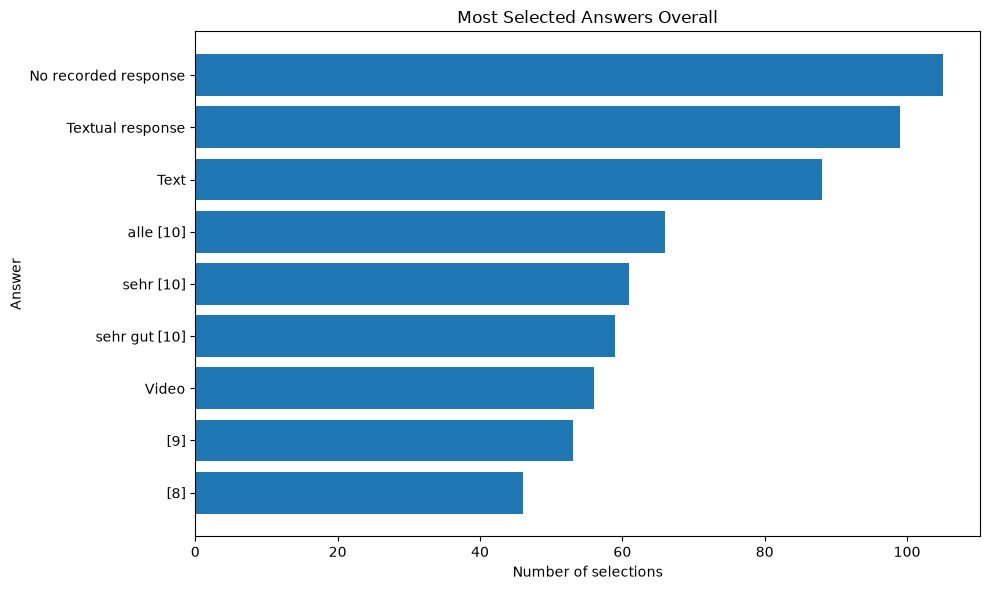

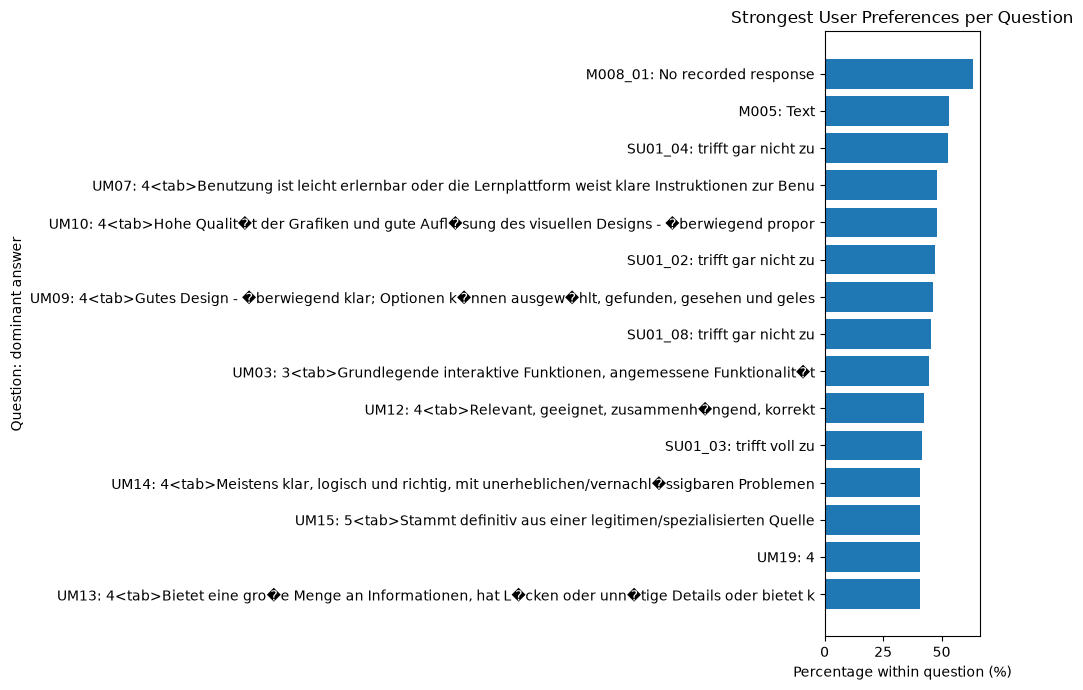


Exported CSV files:
- actual_user_preferences_per_question.csv
- strongest_preferences_per_question.csv
- most_selected_answers_overall.csv
- most_selected_response_labels_overall.csv


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# User Preference Statistics from Questionnaire KG
# Requires the existing run_query() function and PREFIXES.
# ============================================================

# Small helper: make URIs readable in tables and plots
def short_uri(x):
    if pd.isna(x):
        return x
    x = str(x)
    if "#" in x:
        return x.split("#")[-1]
    return x.rstrip("/").split("/")[-1]


def clean_text(x):
    """Clean strings only for display; does not change query results."""
    if pd.isna(x):
        return x
    return str(x).replace("\t", " ").replace("\n", " ").strip()


# ------------------------------------------------------------
# 4. Actual user preferences per question
# ------------------------------------------------------------
# This query counts how many times each answer option was selected for each question.
# It keeps ResponseCode and ResponseLabel because they represent the interpretable answer option.
# rawResponseValue is included only as supporting information, especially for text answers.

q_actual_user_preferences = """
SELECT
    ?questionnaire
    ?questionnaireLabel
    ?question
    ?questionText
    ?answer
    ?responseCode
    ?responseLabel
    ?rawResponseValue
    (COUNT(DISTINCT ?answered) AS ?frequency)
WHERE {
    ?answered ds:answeredInQuestionnaire ?questionnaire ;
              ds:hasQuestion ?question ;
              ds:hasAnswer ?answer .

    OPTIONAL { ?questionnaire rdfs:label ?questionnaireLabel . }
    OPTIONAL { ?question ds:QuestionDescription ?questionText . }
    OPTIONAL { ?answer ds:ResponseCode ?responseCode . }
    OPTIONAL { ?answer ds:ResponseLabel ?responseLabel . }
    OPTIONAL { ?answered ds:rawResponseValue ?rawResponseValue . }
}
GROUP BY
    ?questionnaire
    ?questionnaireLabel
    ?question
    ?questionText
    ?answer
    ?responseCode
    ?responseLabel
    ?rawResponseValue
ORDER BY ?questionnaire ?question DESC(?frequency)
"""

df_preferences = run_query(q_actual_user_preferences)

# Convert count to numeric
if not df_preferences.empty:
    df_preferences["frequency"] = pd.to_numeric(df_preferences["frequency"], errors="coerce").fillna(0).astype(int)

    # Short readable columns
    df_preferences["questionnaire_short"] = df_preferences["questionnaire"].apply(short_uri)
    df_preferences["question_short"] = df_preferences["question"].apply(short_uri)
    df_preferences["answer_short"] = df_preferences["answer"].apply(short_uri)

    # Clean long text columns for readable display
    for col in ["questionnaireLabel", "questionText", "responseCode", "responseLabel", "rawResponseValue"]:
        if col in df_preferences.columns:
            df_preferences[col] = df_preferences[col].apply(clean_text)

    # Build a readable answer label.
    # Priority: ResponseLabel > ResponseCode > rawResponseValue > answer URI
    df_preferences["answer_display"] = (
        df_preferences["responseLabel"]
        .fillna(df_preferences["responseCode"])
        .fillna(df_preferences["rawResponseValue"])
        .fillna(df_preferences["answer_short"])
    )

    # Percentage within each question
    df_preferences["question_total"] = df_preferences.groupby("question")["frequency"].transform("sum")
    df_preferences["percentage_within_question"] = (
        df_preferences["frequency"] / df_preferences["question_total"] * 100
    ).round(2)

    # Sort: strongest preferences first within each question
    df_preferences = df_preferences.sort_values(
        by=["questionnaire_short", "question_short", "frequency"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    print("Actual user preferences per question")
    print("Rows:", len(df_preferences))
    display_cols = [
        "questionnaire_short",
        "questionnaireLabel",
        "question_short",
        "questionText",
        "answer_display",
        "responseCode",
        "responseLabel",
        "frequency",
        "percentage_within_question"
    ]
    display(df_preferences[display_cols].head(50))
else:
    print("No preference data found. Please check ds:hasQuestion, ds:hasAnswer, and answer metadata properties.")


# ------------------------------------------------------------
# Strongest preference per question
# ------------------------------------------------------------
# This table keeps only the most frequently selected answer for each question.

if not df_preferences.empty:
    df_strongest_preferences = (
        df_preferences.sort_values(
            by=["question", "frequency", "percentage_within_question"],
            ascending=[True, False, False]
        )
        .groupby("question", as_index=False)
        .first()
    )

    df_strongest_preferences = df_strongest_preferences.sort_values(
        by="percentage_within_question",
        ascending=False
    ).reset_index(drop=True)

    print("\nStrongest / dominant answer per question")
    display(df_strongest_preferences[display_cols].head(50))


# ------------------------------------------------------------
# 6. Most selected answers overall
# ------------------------------------------------------------
# This query aggregates all selected answers over the whole KG.
# It is useful as a global overview, but per-question percentages are usually more meaningful.

q_most_selected_answers_overall = """
SELECT
    ?answer
    ?responseCode
    ?responseLabel
    (COUNT(DISTINCT ?answered) AS ?frequency)
WHERE {
    ?answered ds:hasAnswer ?answer .

    OPTIONAL { ?answer ds:ResponseCode ?responseCode . }
    OPTIONAL { ?answer ds:ResponseLabel ?responseLabel . }
}
GROUP BY
    ?answer
    ?responseCode
    ?responseLabel
ORDER BY DESC(?frequency)
"""

df_top_answers = run_query(q_most_selected_answers_overall)

if not df_top_answers.empty:
    df_top_answers["frequency"] = pd.to_numeric(df_top_answers["frequency"], errors="coerce").fillna(0).astype(int)
    df_top_answers["answer_short"] = df_top_answers["answer"].apply(short_uri)

    for col in ["responseCode", "responseLabel"]:
        if col in df_top_answers.columns:
            df_top_answers[col] = df_top_answers[col].apply(clean_text)

    df_top_answers["answer_display"] = (
        df_top_answers["responseLabel"]
        .fillna(df_top_answers["responseCode"])
        .fillna(df_top_answers["answer_short"])
    )

    total_selected_answers = df_top_answers["frequency"].sum()
    df_top_answers["percentage_overall"] = (
        df_top_answers["frequency"] / total_selected_answers * 100
    ).round(2)

    df_top_answers = df_top_answers.sort_values("frequency", ascending=False).reset_index(drop=True)

    print("\nMost selected answers overall")
    print("Total selected answers:", total_selected_answers)
    display(df_top_answers[[
        "answer_short",
        "answer_display",
        "responseCode",
        "responseLabel",
        "frequency",
        "percentage_overall"
    ]].head(50))
else:
    print("No selected answers found. Please check ds:hasAnswer.")


# ------------------------------------------------------------
# Overall response labels aggregated by label/code
# ------------------------------------------------------------
# This groups semantically identical labels/codes together, even if they are different answer nodes.
# Example: all occurrences of Likert value 5 can be counted together.

if not df_top_answers.empty:
    df_response_label_stats = (
        df_top_answers
        .groupby(["answer_display", "responseCode", "responseLabel"], dropna=False, as_index=False)["frequency"]
        .sum()
        .sort_values("frequency", ascending=False)
        .reset_index(drop=True)
    )

    total_label_answers = df_response_label_stats["frequency"].sum()
    df_response_label_stats["percentage_overall"] = (
        df_response_label_stats["frequency"] / total_label_answers * 100
    ).round(2)

    print("\nMost selected response labels/codes overall")
    display(df_response_label_stats.head(50))


# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------

# Plot A: Most selected answers overall
if not df_top_answers.empty:
    plot_df = df_top_answers.head(15).copy()
    plot_df["plot_label"] = plot_df["answer_display"].astype(str).str.slice(0, 80)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["plot_label"], plot_df["frequency"])
    plt.gca().invert_yaxis()
    plt.xlabel("Number of selections")
    plt.ylabel("Answer")
    plt.title("Most Selected Answers Overall")
    plt.tight_layout()
    plt.show()

# Plot B: Strongest preference per question
if not df_preferences.empty:
    plot_df = df_strongest_preferences.head(15).copy()
    plot_df["plot_label"] = (
        plot_df["question_short"].astype(str) + ": " + plot_df["answer_display"].astype(str)
    ).str.slice(0, 100)

    plt.figure(figsize=(10, 7))
    plt.barh(plot_df["plot_label"], plot_df["percentage_within_question"])
    plt.gca().invert_yaxis()
    plt.xlabel("Percentage within question (%)")
    plt.ylabel("Question: dominant answer")
    plt.title("Strongest User Preferences per Question")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Optional export for reporting
# ------------------------------------------------------------

if not df_preferences.empty:
    df_preferences.to_csv("actual_user_preferences_per_question.csv", index=False)
    df_strongest_preferences.to_csv("strongest_preferences_per_question.csv", index=False)

if not df_top_answers.empty:
    df_top_answers.to_csv("most_selected_answers_overall.csv", index=False)
    df_response_label_stats.to_csv("most_selected_response_labels_overall.csv", index=False)

print("\nExported CSV files:")
print("- actual_user_preferences_per_question.csv")
print("- strongest_preferences_per_question.csv")
print("- most_selected_answers_overall.csv")
print("- most_selected_response_labels_overall.csv")
